# CLIP-Guided Test-Time Optimization with GigaTok

This notebook demonstrates CLIP-guided image editing and token interpretability using GigaTok's 1D VQ tokenizer with hierarchical ViT encoder/decoder.

In [1]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

In [2]:

import sys
if IN_COLAB:
    # Clone main sandbox repository
    !rm -rf sandbox/
    !git clone -q https://github.com/sbeeredd04/sandbox.git
    # Install required dependencies (including gdown for GigaTok checkpoint downloads)
    %pip install -q --progress-bar off jaxtyping open_clip_torch omegaconf timm safetensors huggingface_hub gdown

    sys.path.insert(0, "sandbox/token-opt")
    sys.path.insert(0, "sandbox/GigaTok")
    sys.path.insert(0, "sandbox/continuous_tokenizer")
    sys.path.insert(0, "sandbox/ImageFolder")
else:
    # For local development
    sys.path.insert(0, "/scratch/sbeeredd/sandbox/token-opt")
    sys.path.insert(0, "/scratch/sbeeredd/sandbox/GigaTok")
    sys.path.insert(0, "/scratch/sbeeredd/sandbox/continuous_tokenizer")
    sys.path.insert(0, "/scratch/sbeeredd/sandbox/ImageFolder")

print("Python path:")
for p in sys.path[:8]:
    print(f"  - {p}")

Python path:
  - /scratch/sbeeredd/sandbox/ImageFolder
  - /scratch/sbeeredd/sandbox/continuous_tokenizer
  - /scratch/sbeeredd/sandbox/GigaTok
  - /scratch/sbeeredd/sandbox/token-opt
  - /etc/python
  - /home/sbeeredd/.conda/envs/myenv/lib/python311.zip
  - /home/sbeeredd/.conda/envs/myenv/lib/python3.11
  - /home/sbeeredd/.conda/envs/myenv/lib/python3.11/lib-dynload


In [3]:
import os
# Set this environment for deterministic execution
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

In [ ]:
import torch
# Enable for deterministic algorithms
torch.use_deterministic_algorithms(True, warn_only=False)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

from pathlib import Path
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as v2
import torchvision.transforms.v2.functional as tvf
from torchvision.datasets import ImageNet
from einops import rearrange
import random

In [ ]:
gpus = "0,1"
os.environ["CUDA_VISIBLE_DEVICES"] = gpus
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_gpus = torch.cuda.device_count()
print(f"Using device: {device}, num_gpus: {num_gpus}")

Using device: cuda, num_gpus: 2


In [ ]:
from tto.test_time_opt import (
    TestTimeOpt,
    TestTimeOptConfig,
    CLIPObjective,
)

/etc/python/sitecustomize.py:117: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  mod = _original_import(name, globals, locals, fromlist, level)
/scratch/sbeeredd/sandbox/continuous_tokenizer/modelling/modules/timm_vit/vision_transformer.py:2186: UserWarning: Overwriting vit_tiny_patch16_224 in registry with modelling.modules.timm_vit.vision_transformer.vit_tiny_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/scratch/sbeeredd/sandbox/continuous_tokenizer/modelling/modules/timm_vit/vision_transformer.py:2205: UserWarning: Overwriting vit_tiny_patch16_384 in registry with modelling.modules.timm_vit.vision_transformer.vit_tiny_patch16_384. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/scratch/sbeeredd/sandbox/continuou

## Utils

In [ ]:
def load_img(path, device=None):
    if IN_COLAB:
        path = Path("sandbox/token-opt/notebooks") / Path(path)
    img = (1. / 255.) * torch.from_numpy(
        np.array(Image.open(path)).astype(np.float32)
    ).permute(2, 0, 1)
    img = tvf.resize(img, 256)
    img = tvf.center_crop(img, 256)
    img = img.unsqueeze(0)
    if device is not None:
        img = img.to(device)
    return img

def display_image(*tensors):
    tensors = [255. * t.squeeze() for t in tensors]
    img = Image.fromarray(rearrange(
        tensors, "b c h w -> h (b w) c"
    ).to("cpu", dtype=torch.uint8).numpy())
    display(img)

def opt_callback(info):
    if info.i % 50 == 0:
        print(f"i = {info.i}")
        print("  CLIP score =", "\t".join(
            map(lambda l: f"{-l:.3f}", info.loss))
        )
        imgs = tto.decode(info.tokens).clamp(0., 1.)
        display_image(*imgs)

# Set up the objective function

In [ ]:
# Use CLIP similarity maximization objective
objective = CLIPObjective(num_augmentations=8, cfg_scale=1.2)

# Set prompt
objective.prompt = [
    "a photo of a tiger",
    "a photo of a husky",
    "a photo of a sparrow",
]

# Optionally set a negative prompt
# Note: also need to set cfg_scale > 1 in CLIPObjective if using this!
objective.neg_prompt = "bad, low-res, unnatural"

## GigaTok Test-Time Optimization

**GigaTok Architecture:**
- 1D VQ tokenizer with hierarchical ViT encoder/decoder
- **BL256**: Base encoder + Large decoder, 256 tokens (faster)
- **XLXXL256**: XL encoder + XXL decoder, 256 tokens (3B params, higher quality)

**Encoding Pipeline:**
1. CNN encoder: (b, 3, 256, 256) → (b, z_channels, h, w)
2. ViT 2D→1D encoder: (b, z_channels, h, w) → (b, 256, z_channels)
3. quant_conv: project to codebook dimension
4. Vector quantization: map to discrete codebook (16,384 entries)

**Optimization Modes:**
- `optimize_post_quantization_tokens=True`: optimize discrete codebook indices (this notebook)
- `optimize_post_quantization_tokens=False`: optimize continuous embeddings

**Decoding Pipeline:**
1. post_quant_conv: expand codebook dim to z_channels
2. ViT 1D→2D decoder: (b, 256, z_channels) → (b, z_channels, h, w)
3. CNN decoder: (b, z_channels, h, w) → (b, 3, 256, 256)

In [12]:
# Configuration for CLIP-guided optimization
tto_config = TestTimeOptConfig(
    titok_checkpoint="gigatok:BL256",  # Use BL256 (Base encoder, Large decoder, 256 tokens)

    # optimize_post_quantization_tokens controls where optimization happens:
    # True  = optimize discrete codebook indices (post-quantization 1D tokens)
    # False = optimize continuous embeddings (pre-quantization)
    optimize_post_quantization_tokens=True,
    vae_deterministic_sampling=True,

    # Optimization parameters (similar to original TiTok notebook)
    # Hard VQ's discrete bottleneck provides implicit regularization,
    # so we can use similar hyperparameters to TiTok
    num_iter=301,
    ema_decay=0.98,
    lr=1e-1,  # Standard learning rate (same as original)
    enable_amp=True,
    reg_weight=0.025,  # Standard regularization (same as original)
    #token_noise=1e-3,
    reg_type="seed",
)

# Initialize test-time optimizer
tto = TestTimeOpt(tto_config, objective).to(device)

Using predefined config: BL256
  Base encoder, Large decoder, 256 tokens (622M params)
  Config path: /scratch/sbeeredd/sandbox/GigaTok/configs/vq/VQ_BL256.yaml

Verifying config file...
  Path: /scratch/sbeeredd/sandbox/GigaTok/configs/vq/VQ_BL256.yaml
  Absolute path: /scratch/sbeeredd/sandbox/GigaTok/configs/vq/VQ_BL256.yaml
  Exists: True
  ✓ Config file exists, loading...
  ✓ Config loaded successfully

No checkpoint provided, auto-downloading pretrained weights...


Using cached checkpoint: pretrained/gigatok/VQ_BL256_e200.pt
Loading checkpoint from pretrained/gigatok/VQ_BL256_e200.pt...
Checkpoint loaded successfully

Model configuration:
  Latent tokens: 256
  Codebook size: 16384
  Codebook dim: 8
  Z channels: 256


In [13]:
# Load seed images for optimization
img = torch.cat([
    load_img("ILSVRC2012_val_00008636.png", device),
    load_img("ILSVRC2012_val_00008636.png", device),
    load_img("ILSVRC2012_val_00010240.png", device),
], dim=0)

seed_tokens = None  # Use images as seed instead of pre-computed tokens

print(f"Loaded {img.shape[0]} seed images")
print(f"Image shape: {img.shape}")


Loaded 3 seed images
Image shape: torch.Size([3, 3, 256, 256])


Encoding seed image to tokens...
Initial tokens shape: torch.Size([3, 8, 1, 256])


Optimization Iterations:   0%|          | 0/301 [00:00<?, ?it/s]

i = 0
  CLIP score = 0.086	0.104	0.195


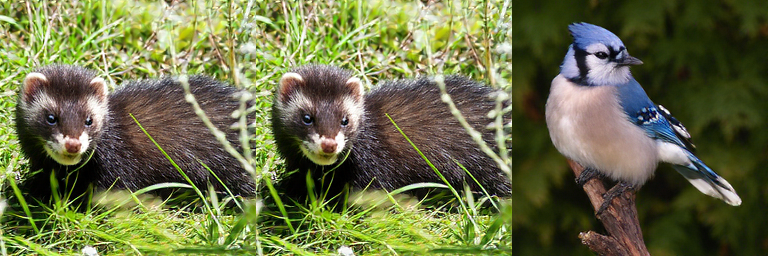

Optimization Iterations:  17%|█▋        | 50/301 [00:14<01:10,  3.58it/s]

i = 50
  CLIP score = 0.315	0.343	0.381


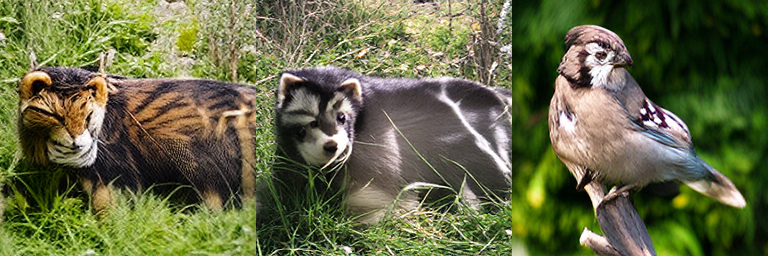

Optimization Iterations:  33%|███▎      | 100/301 [00:28<00:56,  3.57it/s]

i = 100
  CLIP score = 0.337	0.357	0.396


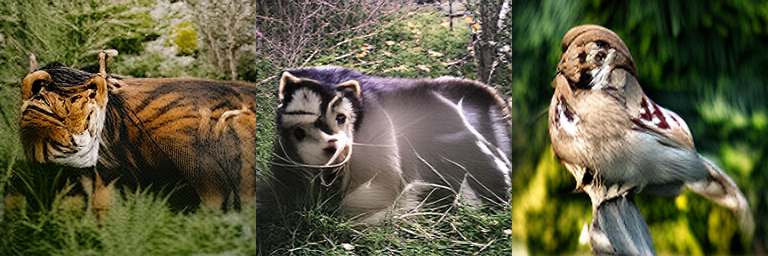

Optimization Iterations:  50%|████▉     | 150/301 [00:43<00:42,  3.57it/s]

i = 150
  CLIP score = 0.350	0.375	0.406


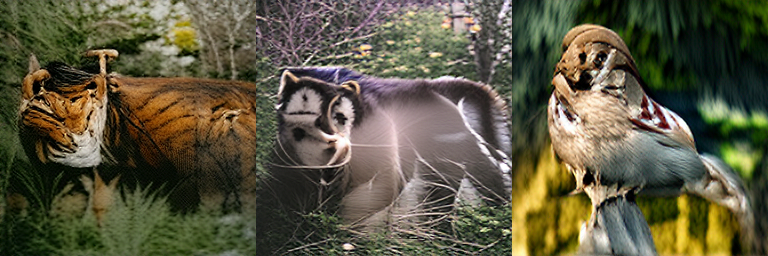

Optimization Iterations:  66%|██████▋   | 200/301 [00:57<00:28,  3.57it/s]

i = 200
  CLIP score = 0.352	0.376	0.411


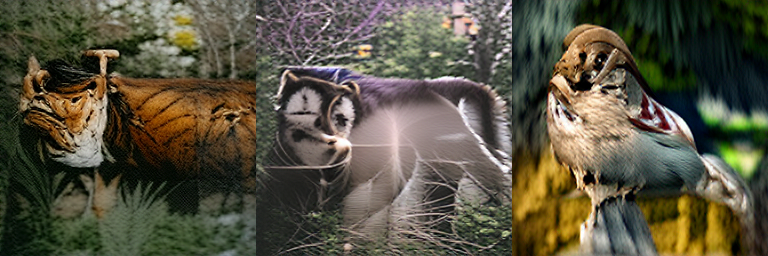

Optimization Iterations:  83%|████████▎ | 250/301 [01:11<00:14,  3.56it/s]

i = 250
  CLIP score = 0.359	0.385	0.413


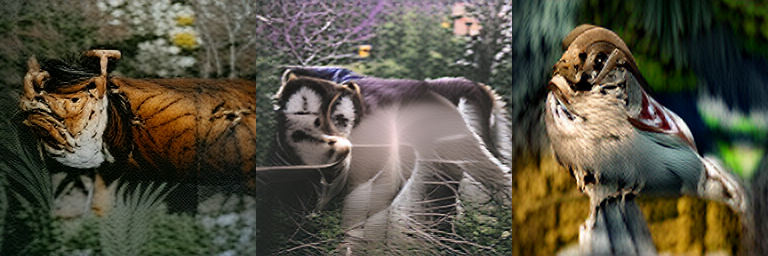

Optimization Iterations: 100%|█████████▉| 300/301 [01:25<00:00,  3.57it/s]

i = 300
  CLIP score = 0.364	0.387	0.415


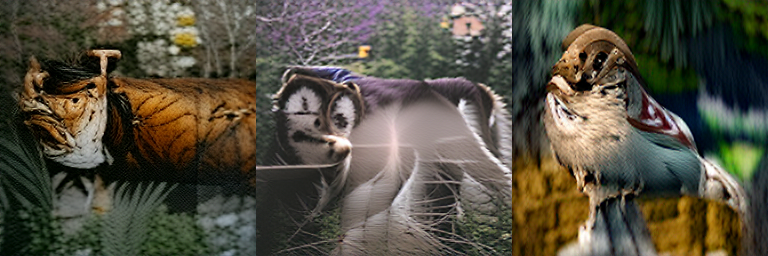

Optimization Iterations: 100%|██████████| 301/301 [01:26<00:00,  3.49it/s]


In [15]:
# Run CLIP-guided optimization
torch.manual_seed(0)

img_opt = tto(
    seed=img if seed_tokens is None else None,
    seed_tokens=seed_tokens,
    callback=opt_callback
)


Final Optimized Images:


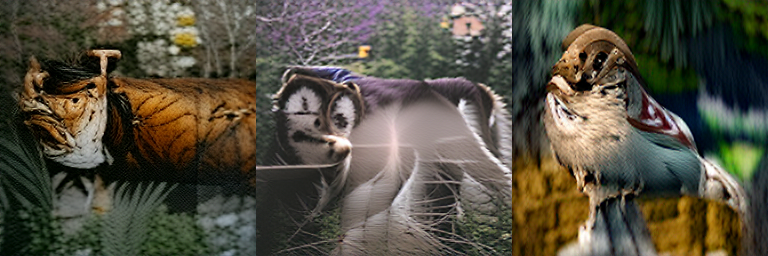


Seed vs Optimized (side-by-side):

Image 1:


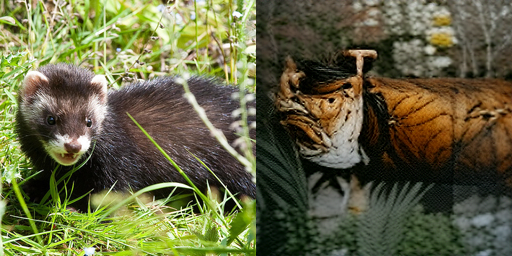


Image 2:


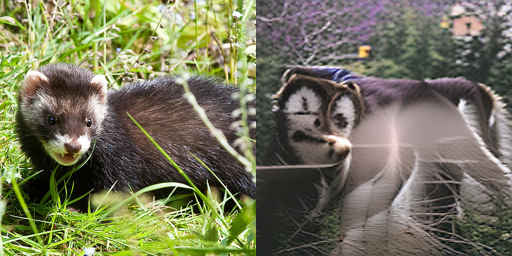


Image 3:


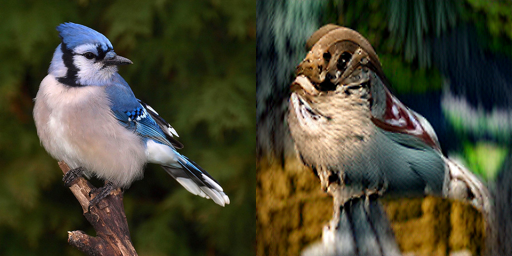

In [16]:
# Display final optimized images
print("Final Optimized Images:")
display_image(*img_opt)

# Display side-by-side comparison
print("\nSeed vs Optimized (side-by-side):")
for i, (seed, opt) in enumerate(zip(img, img_opt)):
    print(f"\nImage {i+1}:")
    display_image(seed, opt)


In [17]:
# Helper functions for token manipulation
def encode_tokens_gigatok(model, img, return_quantized=False):
    with torch.no_grad():
        z = model.encode(img)
        if return_quantized:
            z, _ = model.quantize(z)
        return z

def decode_tokens_gigatok(model, tokens, are_quantized=False):
    with torch.no_grad():
        if not are_quantized:
            tokens, _ = model.quantize(tokens)
        img = model.decode(tokens)
        return img

def swap_token_range(base_tokens, source_tokens, start_idx, end_idx):
    swapped = base_tokens.clone()
    swapped[:, :, :, start_idx:end_idx] = source_tokens[:, :, :, start_idx:end_idx]
    return swapped

In [19]:
# Additional utility functions for visualization
def save_img_tensor(tensor, path):
    tensor = tensor.squeeze().clamp(0., 1.) * 255.
    img_array = tensor.permute(1, 2, 0).cpu().to(dtype=torch.uint8).numpy()
    img = Image.fromarray(img_array)
    img.save(path)
    return img_array

def concat_images(img1, img2):
    img1_np = img1.squeeze().clamp(0., 1.) * 255.
    img1_np = img1_np.permute(1, 2, 0).cpu().to(dtype=torch.uint8).numpy()
    img2_np = img2.squeeze().clamp(0., 1.) * 255.
    img2_np = img2_np.permute(1, 2, 0).cpu().to(dtype=torch.uint8).numpy()
    return np.concatenate([img1_np, img2_np], axis=1)

In [ ]:
import imageio
from PIL import Image
from IPython.display import Image as IPImage # Import IPImage

#load gigaTok model
gigatok_model = tto.titok

# Progressive token swapping visualization
output_dir = Path("gigatok_token_swap_frames")
output_dir.mkdir(exist_ok=True)

# Set whether to quantize tokens immediately
use_quantized_tokens = True

# Load two images for token swapping
img1 = load_img("ILSVRC2012_val_00008636.png", device)
img2 = load_img("ILSVRC2012_val_00010240.png", device)

# Encode to tokens
tokens1_original = encode_tokens_gigatok(gigatok_model, img1, return_quantized=use_quantized_tokens)
tokens2_original = encode_tokens_gigatok(gigatok_model, img2, return_quantized=use_quantized_tokens)

# Get token dimensions
b, d, _, n = tokens1_original.shape
print(f"Token shape: {tokens1_original.shape}")
print(f"Number of tokens: {n}")
print(f"Codebook dimension: {d}")
print(f"{'='*60}\n")

# Collect frames for GIF
frames = []

# Swap tokens progressively (in chunks for efficiency)
chunk_size = 1 # Swap 8 tokens at a time for smoother animation
num_chunks = (n + chunk_size - 1) // chunk_size

print(f"Creating progressive token swap animation ({num_chunks} frames)...")

for chunk_idx in range(num_chunks + 1):
    end_idx = min(chunk_idx * chunk_size, n)
    print(f"Tokens swapped: {end_idx}/{n}...", end="\r")

    # Swap tokens [0:end_idx] between the two images
    pair1_swapped = swap_token_range(tokens1_original, tokens2_original, 0, end_idx)
    pair2_swapped = swap_token_range(tokens2_original, tokens1_original, 0, end_idx)

    # Decode both pairs
    img_pair1 = decode_tokens_gigatok(gigatok_model, pair1_swapped, are_quantized=use_quantized_tokens)
    img_pair2 = decode_tokens_gigatok(gigatok_model, pair2_swapped, are_quantized=use_quantized_tokens)

    # Create side-by-side images
    pair1_concat = concat_images(img1, img_pair1)
    pair2_concat = concat_images(img2, img_pair2)

    # Stack both pairs vertically
    combined_frame = np.concatenate([pair1_concat, pair2_concat], axis=0)

    frames.append(combined_frame)

print(f"\n{'='*60}")
print(f"Progressive token swapping complete!")
print(f"{'='*60}\n")

# Save as GIF
gif_path_combined = output_dir / "token_swap_progressive.gif"
imageio.mimsave(gif_path_combined, frames, duration=100, loop=0)

print(f"GIF saved at {gif_path_combined}")

# Display the combined GIF
print("\nProgressive token swap animation:")
display(IPImage(filename=str(gif_path_combined)))

Token shape: torch.Size([1, 8, 1, 256])
Number of tokens: 256
Codebook dimension: 8

Creating progressive token swap animation (256 frames)...
Tokens swapped: 256/256...
Progressive token swapping complete!



## Individual Token Importance

Now let's see the effect of swapping individual tokens (or small groups) to understand token-level semantics.

Testing individual token group swaps...

Processing: First 8 tokens
  Saved: gigatok_individual_token_swap/swap_tokens_0_8.png
Processing: Tokens 64-72
  Saved: gigatok_individual_token_swap/swap_tokens_0_8.png
Processing: Tokens 64-72
  Saved: gigatok_individual_token_swap/swap_tokens_64_72.png
Processing: Middle tokens (128-136)
  Saved: gigatok_individual_token_swap/swap_tokens_64_72.png
Processing: Middle tokens (128-136)
  Saved: gigatok_individual_token_swap/swap_tokens_128_136.png
Processing: Tokens 192-200
  Saved: gigatok_individual_token_swap/swap_tokens_128_136.png
Processing: Tokens 192-200
  Saved: gigatok_individual_token_swap/swap_tokens_192_200.png
Processing: Last 8 tokens
  Saved: gigatok_individual_token_swap/swap_tokens_192_200.png
Processing: Last 8 tokens
  Saved: gigatok_individual_token_swap/swap_tokens_248_256.png

Individual token swap complete!

  Saved: gigatok_individual_token_swap/swap_tokens_248_256.png

Individual token swap complete!

GIF saved at gigat

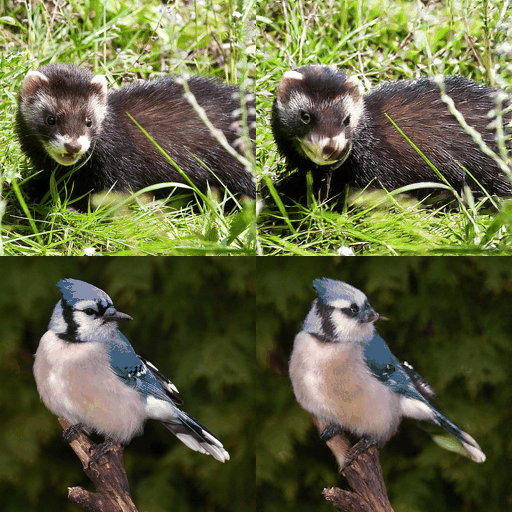

In [ ]:
# Create output directory
output_dir = Path("gigatok_individual_token_swap")
output_dir.mkdir(exist_ok=True)

# Token groups to visualize (beginning, middle, end)
token_positions = [
    (0, 8, "First 8 tokens"),
    (64, 72, "Tokens 64-72"),
    (128, 136, "Middle tokens (128-136)"),
    (192, 200, "Tokens 192-200"),
    (248, 256, "Last 8 tokens"),
]

print("Testing individual token group swaps...\n")

frames = []

for start_idx, end_idx, description in token_positions:
    print(f"Processing: {description}")

    # Swap token range
    pair1_swapped = swap_token_range(tokens1_original, tokens2_original, start_idx, end_idx)
    pair2_swapped = swap_token_range(tokens2_original, tokens1_original, start_idx, end_idx)

    # Decode both pairs
    img_pair1 = decode_tokens_gigatok(gigatok_model, pair1_swapped, are_quantized=use_quantized_tokens)
    img_pair2 = decode_tokens_gigatok(gigatok_model, pair2_swapped, are_quantized=use_quantized_tokens)

    # Create side-by-side images
    pair1_concat = concat_images(img1, img_pair1)
    pair2_concat = concat_images(img2, img_pair2)

    # Stack both pairs vertically
    combined_frame = np.concatenate([pair1_concat, pair2_concat], axis=0)

    # Save individual frame
    frame_pil = Image.fromarray(combined_frame)
    frames.append(np.array(frame_pil))

    frame_path = output_dir / f"swap_tokens_{start_idx}_{end_idx}.png"
    frame_pil.save(frame_path)
    print(f"  Saved: {frame_path}")

print(f"\n{'='*60}")
print(f"Individual token swap complete!")
print(f"{'='*60}\n")

# Save as GIF
gif_path_combined = output_dir / "individual_token_swaps.gif"
imageio.mimsave(gif_path_combined, frames, duration=1500, loop=0)  # 1.5 sec per frame

print(f"GIF saved at {gif_path_combined}")

# Display the GIF
print("\nIndividual token group swap animation:")
display(IPImage(filename=str(gif_path_combined)))

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import json
from PIL import Image
from pathlib import Path

# Dictionary to store selected classes and their prompts
class_names = {}

# Path to imagenet samples
samples_dir = Path("imagenet_samples")

# Get all class folders
class_folders = sorted([d for d in samples_dir.iterdir() if d.is_dir()])

print(f"Found {len(class_folders)} classes in imagenet_samples/")
print("=" * 80)
print("\nInteractive Class Selection")
print("=" * 80)
print("Instructions:")
print("  - First, enter the prompt that will be used for ALL selected classes")
print("  - Then view sample images from each class")
print("  - Input 1 to SELECT the class (will use the prompt you entered)")
print("  - Input 0 to SKIP the class")
print("  - Input 'q' to QUIT and save results")
print("=" * 80)

# Get the prompt ONCE at the beginning
custom_prompt = input("\nEnter the prompt for ALL selected classes (e.g., 'A photo of a husky dog'): ").strip()
if not custom_prompt:
    print("Error: Prompt cannot be empty!")
    raise ValueError("Prompt is required")

print(f"\nUsing prompt: '{custom_prompt}'")
print("=" * 80)

def display_class_samples(class_folder, num_samples=5):
    """Display sample images from a class folder"""
    image_files = sorted(list(class_folder.glob("*.JPEG")))[:num_samples]

    if not image_files:
        print(f"No images found in {class_folder.name}")
        return

    # Create a figure with subplots
    fig, axes = plt.subplots(1, len(image_files), figsize=(15, 3))
    if len(image_files) == 1:
        axes = [axes]

    for ax, img_path in zip(axes, image_files):
        img = Image.open(img_path)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(img_path.name, fontsize=8)

    plt.suptitle(f"Class: {class_folder.name}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Load existing class_names if available
class_names_file = Path("class_names_mapping.json")
if class_names_file.exists():
    with open(class_names_file, 'r') as f:
        class_names = json.load(f)
    print(f"\nLoaded {len(class_names)} existing class mappings from {class_names_file}")
    print("=" * 80)

# Interactive loop
for idx, class_folder in enumerate(class_folders):
    folder_name = class_folder.name

    # Skip if already processed
    if folder_name in class_names:
        continue

    print(f"\n[{idx + 1}/{len(class_folders)}] Processing: {folder_name}")
    print("-" * 80)

    # Display sample images
    display_class_samples(class_folder)

    # Get user input
    while True:
        choice = input(f"\nSelect this class? (1=YES, 0=NO, q=QUIT): ").strip().lower()

        if choice == 'q':
            print("\nQuitting and saving results...")
            break
        elif choice == '1':
            # Use the global custom_prompt
            class_names[folder_name] = custom_prompt
            print(f"✓ Added: {folder_name} -> '{custom_prompt}'")
            break
        elif choice == '0':
            print(f"✗ Skipped: {folder_name}")
            break
        else:
            print("Invalid input. Please enter 1, 0, or q.")

    if choice == 'q':
        break

    # Save progress periodically (every 10 classes)
    if (idx + 1) % 10 == 0:
        with open(class_names_file, 'w') as f:
            json.dump(class_names, f, indent=2)
        print(f"\n[Progress saved: {len(class_names)} classes selected so far]")

# Final save
with open(class_names_file, 'w') as f:
    json.dump(class_names, f, indent=2)

print("\n" + "=" * 80)
print(f"COMPLETE! Selected {len(class_names)} classes for large-scale training")
print(f"Saved to: {class_names_file.absolute()}")
print("=" * 80)

# Display summary
print("\nSummary of selected classes:")
for i, (folder, prompt) in enumerate(list(class_names.items())[:10]):
    print(f"  {i+1}. {folder}: '{prompt}'")
if len(class_names) > 10:
    print(f"  ... and {len(class_names) - 10} more")

Found 1000 classes in imagenet_samples/

Interactive Class Selection
Instructions:
  - First, enter the prompt that will be used for ALL selected classes
  - Then view sample images from each class
  - Input 1 to SELECT the class (will use the prompt you entered)
  - Input 0 to SKIP the class
  - Input 'q' to QUIT and save results
Error: Prompt cannot be empty!



KeyboardInterrupt



## LST

In [ ]:
import json
from pathlib import Path

# Load the class mappings
class_names_file = Path("class_names_mapping.json")

if class_names_file.exists():
    with open(class_names_file, 'r') as f:
        class_names = json.load(f)
    print(f"Loaded {len(class_names)} class mappings")
    print("=" * 80)

    # Display statistics
    print("\nClass Selection Summary:")
    print(f"  Total classes selected: {len(class_names)}")
    print(f"  Total images available: {len(class_names) * 5} (5 per class)")
    print("=" * 80)

    # Create a list of (image_path, prompt) pairs for training
    training_data = []
    samples_dir = Path("imagenet_samples")

    for folder_name, prompt in class_names.items():
        class_folder = samples_dir / folder_name
        if class_folder.exists():
            # Get all images from this class
            image_files = sorted(list(class_folder.glob("*.JPEG")))
            for img_path in image_files:
                training_data.append((str(img_path), prompt))

    print(f"\nPrepared {len(training_data)} image-prompt pairs for training")
    print("=" * 80)

    # Show some examples
    print("\nExample training pairs:")
    for i in range(min(5, len(training_data))):
        img_path, prompt = training_data[i]
        print(f"  {i+1}. {Path(img_path).name}")
        print(f"     → '{prompt}'")

else:
    print(f"No class mappings found at {class_names_file}")
    print("Please run the interactive class selection cell first!")
    class_names = {}
    training_data = []

Loaded 23 class mappings

Class Selection Summary:
  Total classes selected: 23
  Total images available: 115 (5 per class)

Prepared 115 image-prompt pairs for training

Example training pairs:
  1. ILSVRC2012_val_00000082.JPEG
     → 'A photo of a husky dog'
  2. ILSVRC2012_val_00000424.JPEG
     → 'A photo of a husky dog'
  3. ILSVRC2012_val_00005507.JPEG
     → 'A photo of a husky dog'
  4. ILSVRC2012_val_00006143.JPEG
     → 'A photo of a husky dog'
  5. ILSVRC2012_val_00006271.JPEG
     → 'A photo of a husky dog'


In [ ]:
# Run CLIP-guided optimization for all selected classes

import json
import random
from pathlib import Path
from datetime import datetime

# Create output directory for results
output_dir = Path("clip_optimization_results")
output_dir.mkdir(exist_ok=True)

# Load the class mappings
class_names_file = Path("class_names_mapping.json")
with open(class_names_file, 'r') as f:
    class_names = json.load(f)

samples_dir = Path("imagenet_samples")

print(f"Starting CLIP-guided optimization for {len(class_names)} classes")
print("=" * 80)

# Track results
results_log = []

# Set random seed for reproducibility
random.seed(42)

# Maximum images per class (to avoid batch size issues)
MAX_IMAGES_PER_CLASS = 3

# Process each class
for class_idx, (folder_name, prompt) in enumerate(class_names.items(), 1):
    class_folder = samples_dir / folder_name

    print(f"\n{'='*80}")
    print(f"CLASS {class_idx}/{len(class_names)}: {folder_name}")
    print(f"Prompt: '{prompt}'")
    print(f"{'='*80}")

    # Get all images for this class
    image_files = sorted(list(class_folder.glob("*.JPEG")))

    if not image_files:
        print(f"No images found for {folder_name}, skipping...")
        continue

    # Randomly select up to MAX_IMAGES_PER_CLASS images
    if len(image_files) > MAX_IMAGES_PER_CLASS:
        image_files = random.sample(image_files, MAX_IMAGES_PER_CLASS)
        print(f"Found {len(list(class_folder.glob('*.JPEG')))} images, randomly selected {MAX_IMAGES_PER_CLASS}")
    else:
        print(f"Found {len(image_files)} images for this class")

    # Load selected images for this class as seed
    seed_images = []
    for img_path in image_files:
        try:
            img = load_img(str(img_path), device)
            seed_images.append(img)
        except Exception as e:
            print(f"Error loading {img_path.name}: {e}")
            continue

    if not seed_images:
        print(f"⚠ Could not load any images for {folder_name}, skipping...")
        continue

    # Concatenate all seed images
    img_batch = torch.cat(seed_images, dim=0)
    print(f"Loaded batch of {img_batch.shape[0]} images")

    # Reset CLIP objective cache to avoid batch size mismatch
    objective.reset_cache()
    
    # Update objective with current prompt
    objective.prompt = [prompt] * img_batch.shape[0]

    print("\nSeed Images:")
    display_image(*img_batch)

    # Run optimization
    print("\nRunning optimization...")
    torch.manual_seed(0)

    try:
        img_opt = tto(
            seed=img_batch,
            seed_tokens=None,
            callback=opt_callback
        )

        print("\nOptimization complete!")
        print("Final optimized images:")
        display_image(*img_opt)

        # Save optimized images
        class_output_dir = output_dir / folder_name
        class_output_dir.mkdir(exist_ok=True)

        for img_idx, (seed_img, opt_img) in enumerate(zip(img_batch, img_opt)):
            # Save side-by-side comparison
            seed_np = (seed_img.cpu().clamp(0, 1) * 255).permute(1, 2, 0).to(torch.uint8).numpy()
            opt_np = (opt_img.cpu().clamp(0, 1) * 255).permute(1, 2, 0).to(torch.uint8).numpy()

            comparison = np.concatenate([seed_np, opt_np], axis=1)
            comparison_img = Image.fromarray(comparison)
            comparison_img.save(class_output_dir / f"comparison_{img_idx:02d}.png")

        print(f"Saved results to {class_output_dir}")

        results_log.append({
            "class": folder_name,
            "prompt": prompt,
            "num_images": len(seed_images),
            "status": "success"
        })

    except Exception as e:
        print(f"✗ Error during optimization: {e}")
        results_log.append({
            "class": folder_name,
            "prompt": prompt,
            "num_images": len(seed_images),
            "status": "failed",
            "error": str(e)
        })
        continue

print("\n" + "="*80)
print("ALL CLASSES PROCESSED!")
print("="*80)

# Save results log
log_file = output_dir / "optimization_log.json"
with open(log_file, 'w') as f:
    json.dump(results_log, f, indent=2)

print(f"\nResults saved to: {output_dir}")
print(f"Log file: {log_file}")

# Print summary
success_count = sum(1 for r in results_log if r["status"] == "success")
print(f"\nSummary: {success_count}/{len(results_log)} classes optimized successfully")


Starting CLIP-guided optimization for 23 classes

CLASS 1/23: Afghan_hound_n02088094
Prompt: 'A photo of a husky dog'
Found 5 images for this class
Error loading ILSVRC2012_val_00000082.JPEG: name 'load_img' is not defined
Error loading ILSVRC2012_val_00000424.JPEG: name 'load_img' is not defined
Error loading ILSVRC2012_val_00005507.JPEG: name 'load_img' is not defined
Error loading ILSVRC2012_val_00006143.JPEG: name 'load_img' is not defined
Error loading ILSVRC2012_val_00006271.JPEG: name 'load_img' is not defined
⚠ Could not load any images for Afghan_hound_n02088094, skipping...

CLASS 2/23: African_crocodile_n01697457
Prompt: 'A photo of a husky dog'
Found 5 images for this class
Error loading ILSVRC2012_val_00001573.JPEG: name 'load_img' is not defined
Error loading ILSVRC2012_val_00003101.JPEG: name 'load_img' is not defined
Error loading ILSVRC2012_val_00005815.JPEG: name 'load_img' is not defined
Error loading ILSVRC2012_val_00006286.JPEG: name 'load_img' is not defined
Error